In [109]:
import pandas as pd
from pathlib import Path

MIMIC = Path("data/mimic-iv")
NOTES = Path("data/mimic-iv-note")

def preview_table(path, n=5):
    return pd.read_csv(path, nrows=n)

# interested in: admissions.csv.gz, diagnoses_icd.csv.gz, patients.csv.gz, discharge.csv.gz
# preview_table(MIMIC / "hosp/patients.csv.gz")
preview_table(NOTES / "note/discharge.csv.gz")


,note_id,subject_id,hadm_id,note_type,note_seq,charttime,storetime,text
0,10000032-DS-21,10000032,22595853,DS,21,2180-05-07 00:00:00,2180-05-09 15:26:00,\nName: ___ Unit No: _...
1,10000032-DS-22,10000032,22841357,DS,22,2180-06-27 00:00:00,2180-07-01 10:15:00,\nName: ___ Unit No: _...
2,10000032-DS-23,10000032,29079034,DS,23,2180-07-25 00:00:00,2180-07-25 21:42:00,\nName: ___ Unit No: _...
3,10000032-DS-24,10000032,25742920,DS,24,2180-08-07 00:00:00,2180-08-10 05:43:00,\nName: ___ Unit No: _...
4,10000084-DS-17,10000084,23052089,DS,17,2160-11-25 00:00:00,2160-11-25 15:09:00,\nName: ___ Unit No: __...


In [111]:
# Columns for each of the relevant csvs - top 1000 for quick inspection

adm = pd.read_csv(MIMIC / "hosp/admissions.csv.gz", nrows=1000)
diag = pd.read_csv(MIMIC / "hosp/diagnoses_icd.csv.gz", nrows=1000)
notes = pd.read_csv(NOTES / "note/discharge.csv.gz", nrows=1000)

set(adm.columns), set(diag.columns), set(notes.columns)


({'admission_location',
  'admission_type',
  'admit_provider_id',
  'admittime',
  'deathtime',
  'discharge_location',
  'dischtime',
  'edouttime',
  'edregtime',
  'hadm_id',
  'hospital_expire_flag',
  'insurance',
  'language',
  'marital_status',
  'race',
  'subject_id'},
 {'hadm_id', 'icd_code', 'icd_version', 'seq_num', 'subject_id'},
 {'charttime',
  'hadm_id',
  'note_id',
  'note_seq',
  'note_type',
  'storetime',
  'subject_id',
  'text'})

In [113]:
#ICD Labels (9 or 10?)

diag = pd.read_csv(
    MIMIC / "hosp/diagnoses_icd.csv.gz",
    usecols=["hadm_id", "icd_code", "icd_version"]
)

diag["icd_version"].value_counts()

icd_version
10    3455747
9     2908741
Name: count, dtype: int64

<Axes: xlabel='icd_code'>

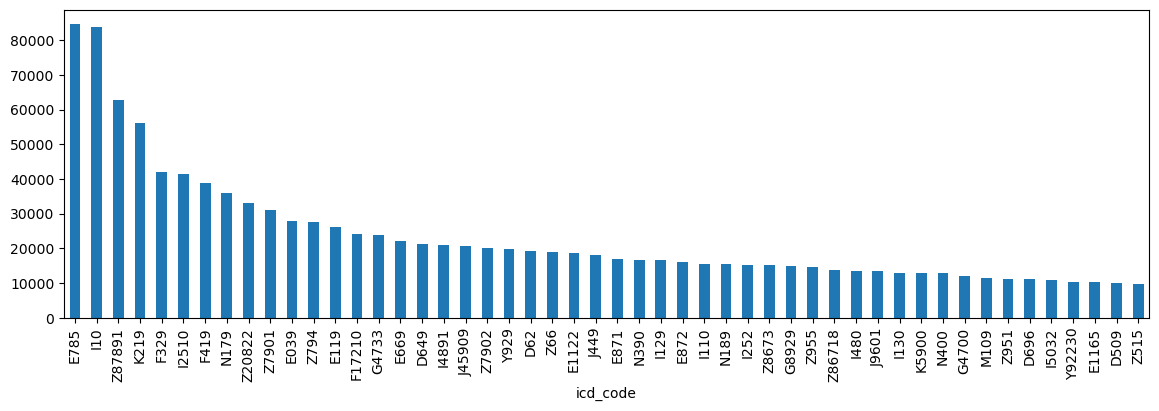

In [115]:
# Frequency Analysis - confirm top 50 scope

icd10 = diag[diag["icd_version"] == 10]

top_codes = (
    icd10.groupby("icd_code")
    .size()
    .sort_values(ascending=False)
)

top_codes.head(50)

# Plot for paper
top_codes.head(50).plot(kind="bar", figsize=(14,4))


In [117]:
# Exploring Clinical Notes

notes = pd.read_csv(
    NOTES / "note/discharge.csv.gz",
    usecols=["hadm_id", "text"]
)

notes["note_length"] = notes["text"].str.len()
notes["note_length"].describe()

count    331793.000000
mean      10550.960270
std        4452.124302
min         353.000000
25%        7462.000000
50%        9847.000000
75%       12831.000000
max       60381.000000
Name: note_length, dtype: float64

In [118]:
# Select a few sample notes to read
# taking 3 samples from the middle of the deck
samples = notes.sample(3, random_state=42) 

for i, row in samples.iterrows():
    print(f"--- NOTE FOR HADM_ID: {row['hadm_id']} ---")
    print(f"Character Count: {row['note_length']}")
    print("-" * 30)
    
    # Print the first 1500 characters so it doesn't fill the whole screen
    print(row['text'][:1500] + "...") 
    
    print("\n" + "="*80 + "\n")

--- NOTE FOR HADM_ID: 28736349 ---
Character Count: 6849
------------------------------
 
Name:  ___                    Unit No:   ___
 
Admission Date:  ___              Discharge Date:   ___
 
Date of Birth:  ___             Sex:   F
 
Service: MEDICINE
 
Allergies: 
Anticholinergics,Other / Reglan
 
Attending: ___.
 
Chief Complaint:
Abdominal pain
 
Major Surgical or Invasive Procedure:
None

 
History of Present Illness:
Patient is a ___ yo woman with history of chronic pancreatitis 
s/p cholecystectomy and sphincterotomy who presents with 1wk of 
worsening abdominal pain. As per patient, the pain is 
intermittent, sharp and ___ in quality. It localizes to her 
mid/righ upper abdomen and radiates up the chest wall and to the 
back. Patient finds this pain to be very similar to her prior 
pancreatitis flare-ups. Denies precipitants including alcohol 
use, abd. trauma, infections or h/o gallstones. She notes that 
she is on a restricted diet (no caffeine/fatty food/fried 
food/dairy

In [119]:
# Modeling Table Prototype

labels = (
    icd10.groupby("hadm_id")["icd_code"]
    .apply(list)
    .reset_index()
)

dataset = notes.merge(labels, on="hadm_id", how="inner")

dataset.head()


,hadm_id,text,note_length,icd_code
0,23052089,\nName: ___ Unit No: __...,9293,"[G3183, F0280, R441, R296, E785, Z8546]"
1,22927623,\nName: ___ Unit No: ___\n...,4637,"[R1310, R0989, K31819, K219, K449, F419, I341,..."
2,27988844,\nName: ___ Unit No: ___\n...,6288,"[S72012A, W010XXA, Y93K1, Y92480, K219, E7800,..."
3,25911675,\nName: ___ Unit No: ___\n \nAdmi...,12536,"[D500, I5023, N184, E118, K2970, Z23, K259, K5..."
4,29659838,\nName: ___ Unit No: ___\n \nAdmi...,11256,"[I5023, N184, D631, E1121, Z86718, I129, Z955,..."


In [120]:
# Document Dataset Statistics

summary = {
    "num_admissions": dataset["hadm_id"].nunique(),
    "avg_note_length": dataset["text"].str.len().mean(),
    "avg_codes_per_admission": dataset["icd_code"].apply(len).mean(),
    "num_unique_codes": len(set(sum(dataset["icd_code"], [])))
}

summary


{'num_admissions': 122288,
 'avg_note_length': 11545.895369946356,
 'avg_codes_per_admission': 14.434981355488683,
 'num_unique_codes': 16155}